In [ ]:
# Task 1
#Random split 80/20 

In [19]:
# import packages 
import scanpy as sc
import pandas as pd
# Data Processing
import pandas as pd
import numpy as np

# Modelling
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import randint

# Tree Visualisation
from sklearn.tree import export_graphviz
from IPython.display import Image

In [2]:
#Load the data
adata = sc.read_h5ad("../data/frangieh/adata_hvg_qc")

In [3]:
# Gene expression are the features
# Perturbation_2 are the treatment condition and is target variable
#Random split the qc done data to 80 /20 
#Train the random forest
#Evaluate via test set 

In [4]:
#Check the treatment condition
print(adata.obs["perturbation_2"].value_counts())

perturbation_2
IFNγ          74186
Co-culture    67093
Control       49895
Name: count, dtype: int64


In [5]:
# Train on highly variable genes
print(adata.var["highly_variable"].value_counts())

highly_variable
False    18711
True      5000
Name: count, dtype: int64


In [6]:
#Subset the data with only hvgs
adata_hvg = adata[:, adata.var["highly_variable"]].copy()
print(adata_hvg.shape)

(191174, 5000)


In [7]:
#import packages
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [8]:
X = adata_hvg.X # imput features
y = adata_hvg.obs["perturbation_2"].values # target variables 

In [9]:
#Split the data now into test and train set 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42, # to make this split reproducable, it can be also 0, 1 etc. 
    stratify=y
)

In [ ]:
import gc
gc.collect()


In [12]:
import time  
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf = RandomForestClassifier(
    n_estimators=100,        # number of trees
    max_depth=15,            # maximum depth of each tree
    min_samples_split=5,     # minimum samples needed to split a node
    min_samples_leaf=2,      # minimum samples in a leaf
    max_features="sqrt",     # number of genes considered at each split
    class_weight="balanced", # useful if perturbation groups are imbalanced
    random_state=42,
    n_jobs=1
)

start = time.time()

rf.fit(X_train, y_train)

end = time.time()

print(f"Training time: {(end - start) / 60:.2f} minutes") # test for the future how many minutes

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Training time: 6.89 minutes
Accuracy: 0.9776905976199817
              precision    recall  f1-score   support

  Co-culture       1.00      0.98      0.99     13419
     Control       0.92      1.00      0.96      9979
        IFNγ       1.00      0.96      0.98     14837

    accuracy                           0.98     38235
   macro avg       0.97      0.98      0.98     38235
weighted avg       0.98      0.98      0.98     38235



In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

# Hyperparameter values to search
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 6, 9, 12],
    'min_samples_split': [2, 4, 6, 8],
    'min_samples_leaf': [1, 2, 3, 4]
}

# Create Random Forest classifier
rf = RandomForestClassifier(
    random_state=42,
    n_jobs= 3
)

# Randomized search
rand_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=3,              # Number of random combinations to evaluate
    cv=3,
    scoring='accuracy',
    n_jobs=3,
    random_state=42,
    verbose=2
)

# Fit the model
rand_search.fit(X_train, y_train)

# Best parameters
print("Best parameters:")
print(rand_search.best_params_)

# Best cross-validation score
print(f"Best CV accuracy: {rand_search.best_score_:.4f}")

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best parameters:
{'n_estimators': 200, 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_depth': 9}
Best CV accuracy: 0.9746


In [15]:
# Create a variable for the best model
best_rf = rand_search.best_estimator_

# Print the best hyperparameters
print('Best hyperparameters:',  rand_search.best_params_)

Best hyperparameters: {'n_estimators': 200, 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_depth': 9}


In [ ]:
# best hyperparameters 200 trees, 4 split min_samples_leaf = 4, max depth = 9

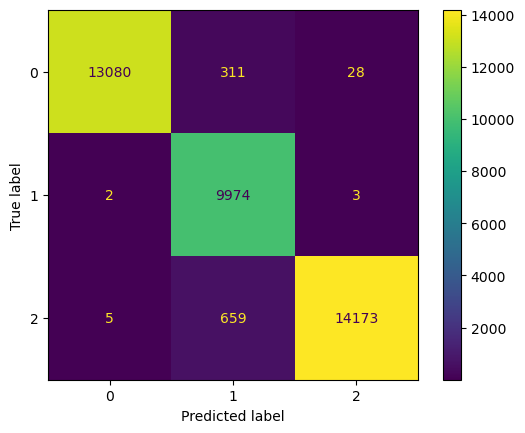

In [20]:
# Generate predictions with the best model
y_pred = best_rf.predict(X_test)

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(confusion_matrix=cm).plot();


In [24]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9736367202824637


In [ ]:
#ey hyperparameters for random forest include the number of trees, 
#the maximum depth of each tree, the minimum number of samples required to split a node, 
#and the number of features to consider for each split.

In [26]:
#For feature importance (genes names) check the column in adata_hvg
print(adata_hvg.var_names)

Index(['AADAC', 'AATBC', 'ABCA1', 'ABCA13', 'ABCA2', 'ABCA7', 'ABCB1',
       'ABCB11', 'ABCB6', 'ABCC12',
       ...
       'ZNF80', 'ZNF841', 'ZNF844', 'ZNF862', 'ZNF92', 'ZNFX1', 'ZNHIT6',
       'ZSCAN5B', 'ZWINT', 'ZXDB'],
      dtype='object', name='gene_symbol', length=5000)


In [28]:
import pandas as pd

# Best Random Forest model
best_rf = rand_search.best_estimator_

# Feature importance
gene_importance = pd.DataFrame({
    "Gene": adata_hvg.var_names,
    "Importance": best_rf.feature_importances_
})

# Sort by importance 
gene_importance = gene_importance.sort_values(
    by="Importance",
    ascending=False
)

# Show top 100 genes
top100 = gene_importance.head(100)
print(top100)

# Save top 100 genes as csv file
top100.to_csv("RandomForest_Top100_Genes.csv", index=False)

print("Top 100 genes saved as 'RandomForest_Top100_Genes.csv'")

       Gene  Importance
4863   WARS    0.036050
2772   IDO1    0.035589
1826   CD74    0.033602
1553    B2M    0.032297
4495  STAT1    0.029794
...     ...         ...
3868  PHGDH    0.002135
4891   XRN1    0.002124
4724  TRIB3    0.001941
4610  THBS1    0.001914
2501   GBP3    0.001906

[100 rows x 2 columns]
Top 100 genes saved as 'RandomForest_Top100_Genes.csv'


In [29]:
# Save the data
adata_hvg_RF = adata_hvg.copy()
adata_hvg_RF = adata.write_h5ad("../data/frangieh/adata_hvg_RF")

In [30]:
#Check the overfitting
from sklearn.metrics import accuracy_score

best_rf = rand_search.best_estimator_

# Training accuracy
train_pred = best_rf.predict(X_train)
train_acc = accuracy_score(y_train, train_pred)

# Test accuracy
test_pred = best_rf.predict(X_test)
test_acc = accuracy_score(y_test, test_pred)

print(f"Training accuracy: {train_acc:.4f}")
print(f"Test accuracy:     {test_acc:.4f}")

Training accuracy: 0.9763
Test accuracy:     0.9736


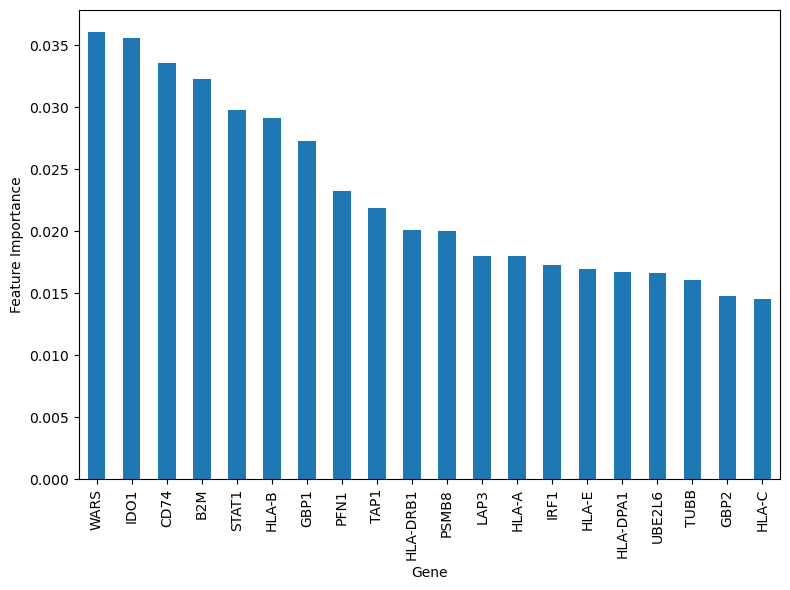

In [39]:
# Create a series containing feature importances from the model and feature names from the training data
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(
    best_rf.feature_importances_,
    index=adata_hvg.var_names
)

# Plot the 50 most important genes
plt.figure(figsize=(8,6))
importances.sort_values(ascending=False).head(20).plot(kind="bar")
plt.ylabel("Feature Importance")
plt.xlabel("Gene")
plt.tight_layout()

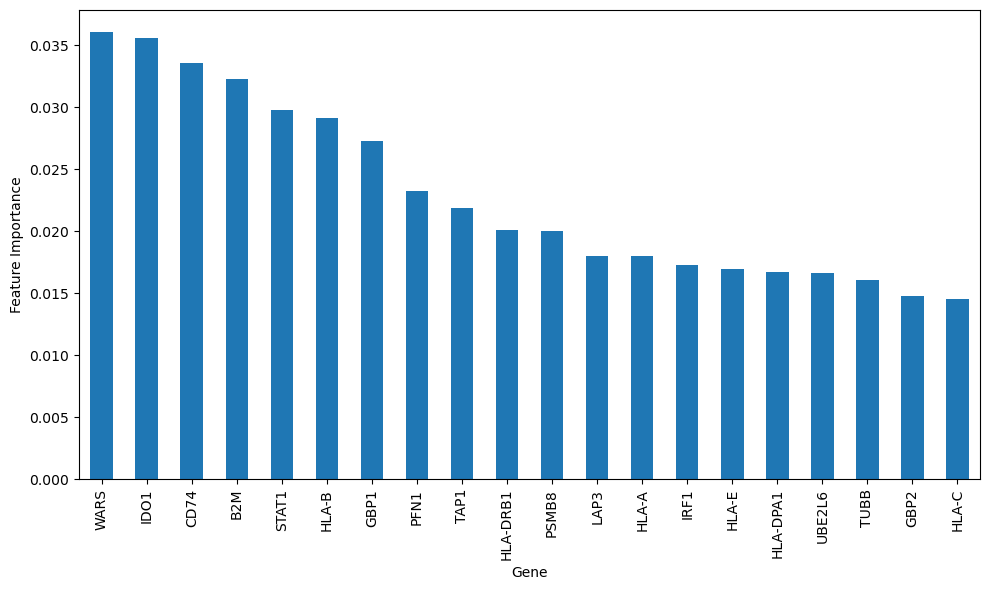

Plot saved to: C:\Users\Deniz Korkmazel\OneDrive\Documents\Uni Heidelberg Molekulare Biotechnologie\Master 2_semester\ML_AI_Seminar\Task_1_top20.png


In [43]:
# Save the feature importance plot
import pandas as pd
import matplotlib.pyplot as plt

# Create feature importance series
importances = pd.Series(
    best_rf.feature_importances_,
    index=adata_hvg.var_names
)

# Select top 50 genes
top20 = importances.sort_values(ascending=False).head(20)

# Figure axis
fig, ax = plt.subplots(figsize=(10, 6))

top20.plot(kind="bar", ax=ax)

ax.set_ylabel("Feature Importance")
ax.set_xlabel("Gene")
plt.xticks(rotation=90)
plt.tight_layout()

# Save the figure
output_path = r"C:\Users\Deniz Korkmazel\OneDrive\Documents\Uni Heidelberg Molekulare Biotechnologie\Master 2_semester\ML_AI_Seminar\Task_1_top20.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Plot saved to: {output_path}")

In [ ]:
#Idea : Train on Top PCs and then search for features on the top PCs

In [44]:
# 2. Idea Train Random forest on PCs in adata_hvg dataset
import scanpy as sc
sc.pp.pca(adata_hvg, n_comps=50)

In [45]:
adata_hvg.obsm["X_pca"]
adata_hvg.varm["PCs"]

array([[-1.68308048e-04, -1.45087630e-04, -1.13107817e-04, ...,
        -4.34957125e-04, -1.64463389e-04,  4.72282118e-04],
       [-1.70829117e-05,  1.59195008e-06,  1.79422364e-06, ...,
         8.79396175e-05, -1.13673605e-06, -4.82941905e-05],
       [-8.18339176e-03,  2.66845222e-03,  6.54103758e-04, ...,
         2.31655012e-03,  5.91831934e-03, -1.01778819e-03],
       ...,
       [-5.07789809e-06, -4.25413100e-06, -8.95876474e-06, ...,
        -1.11727168e-04,  4.83531585e-06,  1.23323262e-04],
       [ 2.94924118e-02, -2.52476800e-02,  3.85107920e-02, ...,
         1.00499857e-02, -3.17445025e-04,  5.51680336e-03],
       [-4.15589748e-04, -1.18081116e-04,  7.07377912e-05, ...,
         1.90183418e-04, -1.05785257e-04,  1.22265847e-04]],
      shape=(5000, 50))

In [46]:
X = adata_hvg.obsm["X_pca"][:, :50]

In [47]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [48]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

# Hyperparameter values to search
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 6, 9, 12],
    'min_samples_split': [2, 4, 6, 8],
    'min_samples_leaf': [1, 2, 3, 4]
}

# Create Random Forest classifier
rf = RandomForestClassifier(
    random_state=42,
    n_jobs= 3
)

# Randomized search
rand_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=3,              # Number of random combinations to evaluate
    cv=3,
    scoring='accuracy',
    n_jobs=3,
    random_state=42,
    verbose=2
)

# Fit the model
rand_search.fit(X_train, y_train)

# Best parameters
print("Best parameters:")
print(rand_search.best_params_)

# Best cross-validation score
print(f"Best CV accuracy: {rand_search.best_score_:.4f}")

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best parameters:
{'n_estimators': 200, 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_depth': 9}
Best CV accuracy: 0.9783


In [52]:
# PCs importance for random forest
best_rf = rand_search.best_estimator_
pc_importance = best_rf.feature_importances_
print(pc_importance)

[3.88173606e-01 3.59505455e-01 1.17006023e-01 7.88583923e-03
 1.64759406e-02 1.48670697e-02 1.47120800e-02 3.83274589e-03
 1.21297459e-02 5.26602160e-03 4.40590983e-03 1.45088514e-03
 5.42380099e-03 1.18130329e-03 4.67778926e-03 3.36303424e-03
 2.12098808e-03 1.66497456e-03 1.09959358e-03 6.04507617e-04
 1.61826397e-03 1.17904525e-03 1.34676543e-03 2.96791051e-03
 9.48791945e-04 1.02112136e-03 1.02103088e-03 9.22367484e-04
 7.63559802e-04 1.61160157e-03 8.62881813e-04 6.73207372e-04
 4.79286886e-03 1.65690573e-03 8.79586212e-04 1.28943697e-03
 1.23140764e-03 1.14453034e-03 7.95646575e-04 3.64395514e-04
 6.63483220e-04 3.96925018e-04 9.99931152e-04 4.53063529e-04
 7.82340440e-04 1.13217358e-03 3.98749036e-04 7.86786693e-04
 1.11342690e-03 3.34480752e-04]


In [55]:
#Check the overfitting
from sklearn.metrics import accuracy_score

best_rf = rand_search.best_estimator_

# Training accuracy
train_pred = best_rf.predict(X_train)
train_acc = accuracy_score(y_train, train_pred)

# Test accuracy
test_pred = best_rf.predict(X_test)
test_acc = accuracy_score(y_test, test_pred)

print(f"Training accuracy: {train_acc:.4f}")
print(f"Test accuracy:     {test_acc:.4f}")
print(rand_search.best_score_)

Training accuracy: 0.9812
Test accuracy:     0.9771
0.9783246851288876


In [50]:
loadings = adata_hvg.varm["PCs"]

In [51]:
gene_scores = np.abs(loadings) @ pc_importance

In [56]:
import pandas as pd

gene_scores = pd.Series(
    gene_scores,
    index=adata_hvg.var_names
)
top_genes = gene_scores.sort_values(ascending=False)
print(top_genes.head(20))

gene_symbol
HLA-B       0.137386
CD74        0.131462
GBP1        0.117238
WARS        0.114113
STAT1       0.106294
UBE2L6      0.094310
IDO1        0.092833
HLA-DRA     0.090009
HLA-DRB1    0.087537
B2M         0.087321
PSMB8       0.086841
IRF1        0.080933
TOP2A       0.079929
UBE2C       0.079808
CENPF       0.078974
TUBA1B      0.078207
PSMB9       0.077801
HLA-A       0.076689
CCNB1       0.076644
TAP1        0.076062
dtype: float64


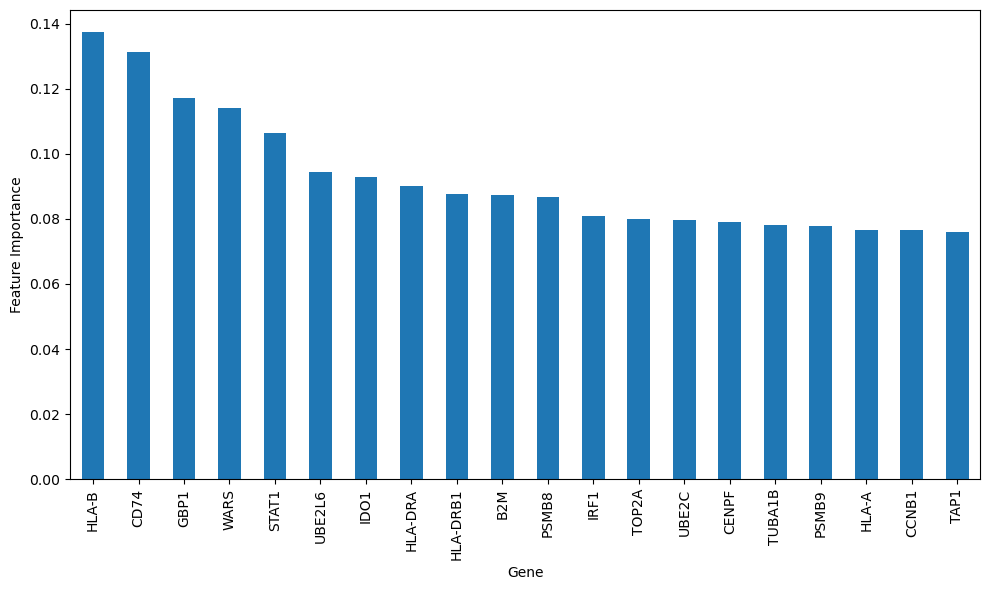

In [57]:
# Save as plot
import pandas as pd
import matplotlib.pyplot as plt

top20 = gene_scores.sort_values(ascending=False).head(20)

# Figure axis
fig, ax = plt.subplots(figsize=(10, 6))

top20.plot(kind="bar", ax=ax)

ax.set_ylabel("Feature Importance")
ax.set_xlabel("Gene")
plt.xticks(rotation=90)
plt.tight_layout()

# Save the figure
output_path = r"C:\Users\Deniz Korkmazel\OneDrive\Documents\Uni Heidelberg Molekulare Biotechnologie\Master 2_semester\ML_AI_Seminar\Task_1_top20.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")

plt.show()